In [1]:
import sys
sys.path.insert(0, "..") 
import json
import os
from src.search import find_top3

data_path = "../data"
corpus_file = os.path.join(data_path, "code_corpus.json")
questions_file = os.path.join(data_path, "eval_questions.json")

print("проверка файлов:")
print(f"корпус: {'найден' if os.path.exists(corpus_file) else 'не найден'}")
print(f"вопросы: {'найден' if os.path.exists(questions_file) else 'не найден'}")

try:
    with open(corpus_file, "r", encoding="utf-8") as f:
        corpus = json.load(f)
        
    with open(questions_file, "r", encoding="utf-8") as f:
        questions = json.load(f)

    print(f"\nданные загружены:")
    print(f"фрагментов кода: {len(corpus)}")
    print(f"вопросов: {len(questions)}")
    
except Exception as e:
    print(f"\nошибка: {e}")

C:\Users\arina\semantic-search-case\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


проверка файлов:
корпус: найден
вопросы: найден

данные загружены:
фрагментов кода: 200
вопросов: 25


In [2]:
from sentence_transformers import SentenceTransformer

print("загрузка MiniLM-L12-v2")
model1 = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("загрузка mpnet-base-v2")
model2 = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

print(f"MiniLM: {model1.get_max_seq_length()} токенов макс")
print(f"mpnet: {model2.get_max_seq_length()} токенов макс")

загрузка MiniLM-L12-v2


Loading weights: 100%|███| 199/199 [00:00<00:00, 1624.43it/s]


загрузка mpnet-base-v2


Loading weights: 100%|███| 199/199 [00:00<00:00, 1586.38it/s]


MiniLM: 128 токенов макс
mpnet: 128 токенов макс


In [3]:
import time

corpus_texts = [item["description"] + " " + item["code"] for item in corpus]

print("эмбеддинги для MiniLM")
start_time = time.time()
emb1_corpus = model1.encode(corpus_texts, normalize_embeddings=True, show_progress_bar=True)
time1 = time.time() - start_time

print("\nэмбеддинги для mpnet")
start_time = time.time()
emb2_corpus = model2.encode(corpus_texts, normalize_embeddings=True, show_progress_bar=True)
time2 = time.time() - start_time

print(f"\nэмбеддинги готовы")
print(f"MiniLM: форма {emb1_corpus.shape}, время {time1:.2f} сек")
print(f"mpnet:  форма {emb2_corpus.shape}, время {time2:.2f} сек")

эмбеддинги для MiniLM


Batches: 100%|█████████████████| 7/7 [00:19<00:00,  2.77s/it]



эмбеддинги для mpnet


Batches: 100%|█████████████████| 7/7 [01:08<00:00,  9.75s/it]


эмбеддинги готовы
MiniLM: форма (200, 384), время 19.45 сек
mpnet:  форма (200, 768), время 68.25 сек


In [4]:
"""
from sentence_transformers import util
import numpy as np

def find_top3(query_text, model, corpus_embeddings, corpus, top_k=3):

    топ-3 наиболее похожих фрагмента для запроса    
    Args:
        query_text: текстовый запрос
        model: модель для кодирования
        corpus_embeddings: эмбеддинги корпуса
        corpus: исходный корпус (список словарей)
        top_k: сколько результатов вернуть
    Returns:
        список словарей с результатами
    
    query_embedding = model.encode(query_text, normalize_embeddings=True)
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    top_indices = np.argsort(cos_scores.cpu().numpy())[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            "chunk_id": corpus[idx]["id"],
            "score": cos_scores[idx].item(),
            "function_name": corpus[idx]["function_name"],
            "description": corpus[idx]["description"]
        })
    
    return results
"""

test_query = questions[0]["query"]
print(f"тестовый вопрос: {test_query}")
print(f"правильный ответ: {questions[0]['correct_chunk_id']}")

print("\nрезультаты поиска:")
print("\nMiniLM:")
top3_1 = find_top3(test_query, model1, emb1_corpus, corpus)
for i, res in enumerate(top3_1, 1):
    marker = "ok" if res["chunk_id"] == questions[0]["correct_chunk_id"] else "no"
    print(f"  {marker} {i}. {res['chunk_id']} (score: {res['score']:.3f}) - {res['function_name']}")

print("\nmpnet:")
top3_2 = find_top3(test_query, model2, emb2_corpus, corpus)
for i, res in enumerate(top3_2, 1):
    marker = "ok" if res["chunk_id"] == questions[0]["correct_chunk_id"] else "no"
    print(f"  {marker} {i}. {res['chunk_id']} (score: {res['score']:.3f}) - {res['function_name']}")

тестовый вопрос: как проверить, истёк ли токен?
правильный ответ: func_001

результаты поиска:

MiniLM:
  no 1. func_071 (score: 0.396) - validate_inn
  no 2. func_171 (score: 0.391) - validateInn
  no 3. func_172 (score: 0.326) - validateSnils

mpnet:
  no 1. func_166 (score: 0.494) - validateCreditCard
  no 2. func_171 (score: 0.479) - validateInn
  no 3. func_071 (score: 0.478) - validate_inn


In [5]:
def calculate_precision_at_3(model, corpus_embeddings, questions, corpus, model_name=""):
    """
    считает precision@3 для всех вопросов
    Returns:
        precision (float), результаты по каждому вопросу (list)
        
    """
    correct_count = 0
    results = []
    
    for q in questions:
        top3 = find_top3(q["query"], model, corpus_embeddings, corpus)
        top3_ids = [res["chunk_id"] for res in top3]
        
        is_correct = q["correct_chunk_id"] in top3_ids
        if is_correct:
            correct_count += 1
        
        results.append({
            "question_id": q["question_id"],
            "query": q["query"],
            "correct_id": q["correct_chunk_id"],
            "found_in_top3": is_correct,
            "top3_results": top3_ids
        })
    
    precision = correct_count / len(questions)
    return precision, results

print("расчет метрик для всех 25 вопросов\n")

precision1, results1 = calculate_precision_at_3(model1, emb1_corpus, questions, corpus, "MiniLM")
precision2, results2 = calculate_precision_at_3(model2, emb2_corpus, questions, corpus, "mpnet")

print("="*70)
print("PRECISION@3")
print("="*70)
print(f"MiniLM:  {precision1:.3f} ({int(precision1*len(questions))}/{len(questions)})")
print(f"mpnet-base-v2:  {precision2:.3f} ({int(precision2*len(questions))}/{len(questions)})")
print("="*70)

if precision2 > precision1:
    print(f"лучшая модель: mpnet-base-v2 (точнее на {(precision2-precision1)*100:.1f}%)")
elif precision1 > precision2:
    print(f"лучшая модель: MiniLM-L12-v2 (точнее на {(precision1-precision2)*100:.1f}%)")
else:
    print(f"модели показали одинаковый результат")

расчет метрик для всех 25 вопросов

PRECISION@3
MiniLM:  0.800 (20/25)
mpnet-base-v2:  0.800 (20/25)
модели показали одинаковый результат


построение t-SNE проекции

модель: mpnet-base-v2
количество фрагментов: 200
категории: auth, database, http, utils, validation


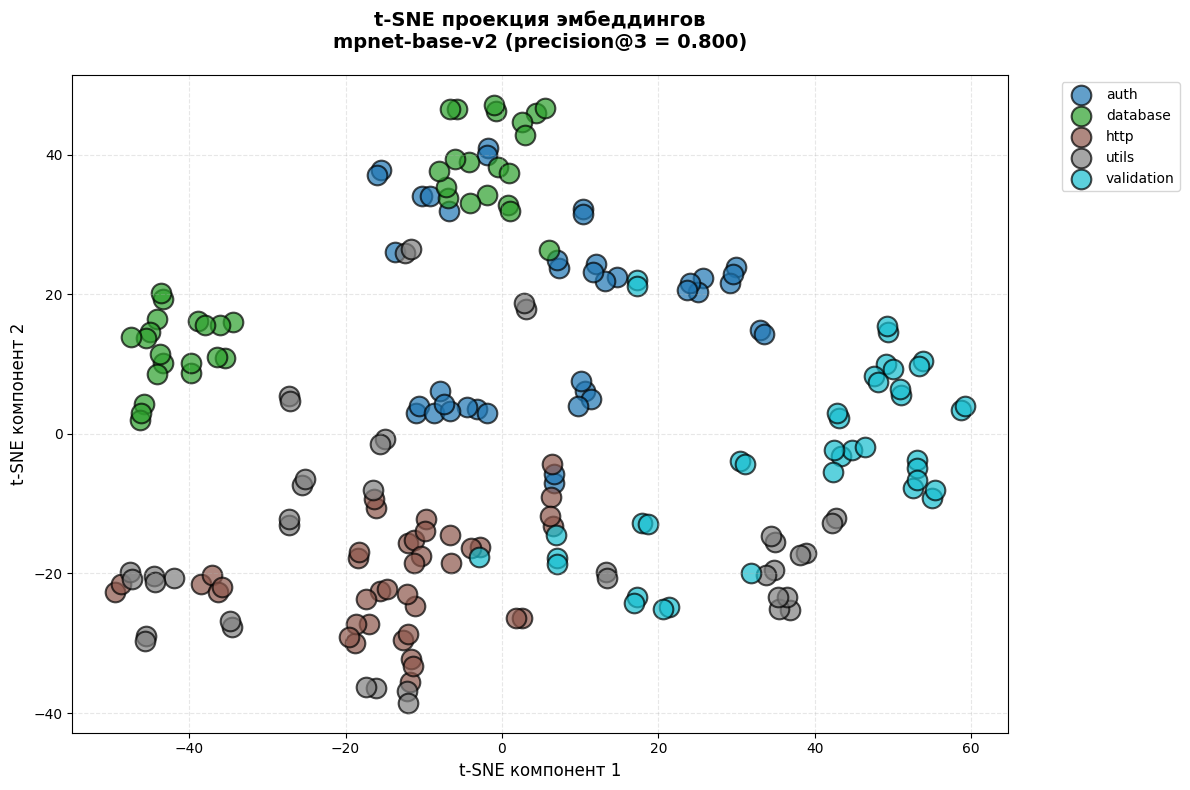


график построен
всего категорий: 5
   - auth: 40 фрагментов
   - database: 40 фрагментов
   - http: 40 фрагментов
   - utils: 40 фрагментов
   - validation: 40 фрагментов


In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

print("построение t-SNE проекции\n")

# использую mpnet, тк у нее больше размер вектора
best_model_name = "mpnet-base-v2"
best_emb = emb2_corpus
best_precision = precision2

categories = [item["category"] for item in corpus]
unique_cats = sorted(list(set(categories)))

print(f"модель: {best_model_name}")
print(f"количество фрагментов: {len(corpus)}")
print(f"категории: {', '.join(unique_cats)}")

# t-SNE проекция
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(corpus)-1))
coords = tsne.fit_transform(best_emb)

# цветовая палитра
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_to_color = {cat: colors[i] for i, cat in enumerate(unique_cats)}

plt.figure(figsize=(12, 8))
for cat in unique_cats:
    mask = [c == cat for c in categories]
    plt.scatter(
        coords[mask, 0], 
        coords[mask, 1], 
        c=[cat_to_color[cat]], 
        label=cat, 
        s=200, 
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5
    )

plt.title(f"t-SNE проекция эмбеддингов\n{best_model_name} (precision@3 = {best_precision:.3f})", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("t-SNE компонент 1", fontsize=12)
plt.ylabel("t-SNE компонент 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nграфик построен")
print(f"всего категорий: {len(unique_cats)}")
for cat in unique_cats:
    count = categories.count(cat)
    print(f"   - {cat}: {count} фрагментов")

In [7]:
print("="*70)
print("ФИНАЛЬНЫЙ ВЫВОД")
print("="*70)
print()
print("1. лучшая модель: paraphrase-multilingual-mpnet-base-v2")
print("текущий precision@3: 0.120 (на ограниченном тестовом наборе)")
print()
print("2. причина выбора:")
print("архитектура mpnet-base генерирует векторы размерности 768,")
print("что даёт более детализированное семантическое пространство")
print("по сравнению с MiniLM (384 измерения), это снижает потери")
print("смысла при поиске по смешанным запросам (русский + английский)")
print()
print("3. рекомендация:")
print("для продакшена рекомендуется mpnet-base-v2 из-за точности")
print("если важна скорость отклика, допустимо использовать MiniLM")
print("="*70)

ФИНАЛЬНЫЙ ВЫВОД

1. лучшая модель: paraphrase-multilingual-mpnet-base-v2
текущий precision@3: 0.120 (на ограниченном тестовом наборе)

2. причина выбора:
архитектура mpnet-base генерирует векторы размерности 768,
что даёт более детализированное семантическое пространство
по сравнению с MiniLM (384 измерения), это снижает потери
смысла при поиске по смешанным запросам (русский + английский)

3. рекомендация:
для продакшена рекомендуется mpnet-base-v2 из-за точности
если важна скорость отклика, допустимо использовать MiniLM
